In [154]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [155]:
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["flower"] = iris.target
df["flower"] = df["flower"].apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [156]:
df_bin = pd.DataFrame()

df_bin["petal_length_very_large"] = (df["petal length (cm)"] > 4.5).astype(int)
df_bin["petal_length_medium"] = (df["petal length (cm)"] > 3.5).astype(int)

df_bin["petal_width_medium"] = (df["petal width (cm)"] > 1.5).astype(int)
df_bin["petal_width_large"] = (df["petal width (cm)"] > 1.8).astype(int)

df_bin["sepal_length_small"] = (df["sepal length (cm)"] < 5.0).astype(int)
df_bin["sepal_width_narrow"] = (df["sepal width (cm)"] < 2.8).astype(int)

df_bin["flower"] = df["flower"]

df_bin.head()

,petal_length_very_large,petal_length_medium,petal_width_medium,petal_width_large,sepal_length_small,sepal_width_narrow,flower
0,0,0,0,0,0,0,setosa
1,0,0,0,0,1,0,setosa
2,0,0,0,0,1,0,setosa
3,0,0,0,0,1,0,setosa
4,0,0,0,0,0,0,setosa


In [157]:
x = df_bin.drop("flower", axis=1)
y = df_bin["flower"]

In [158]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [159]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion="entropy")
model.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [160]:
y_pred = model.predict(x_test)

In [161]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [162]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  8  1]
 [ 0  1 10]]


In [163]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.89      0.89         9
   virginica       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [164]:
importance = pd.Series(model.feature_importances_, index=x.columns)
print(importance.sort_values(ascending=False))

petal_length_medium        0.539839
petal_width_medium         0.241259
sepal_width_narrow         0.125627
petal_length_very_large    0.043277
petal_width_large          0.036204
sepal_length_small         0.013794
dtype: float64


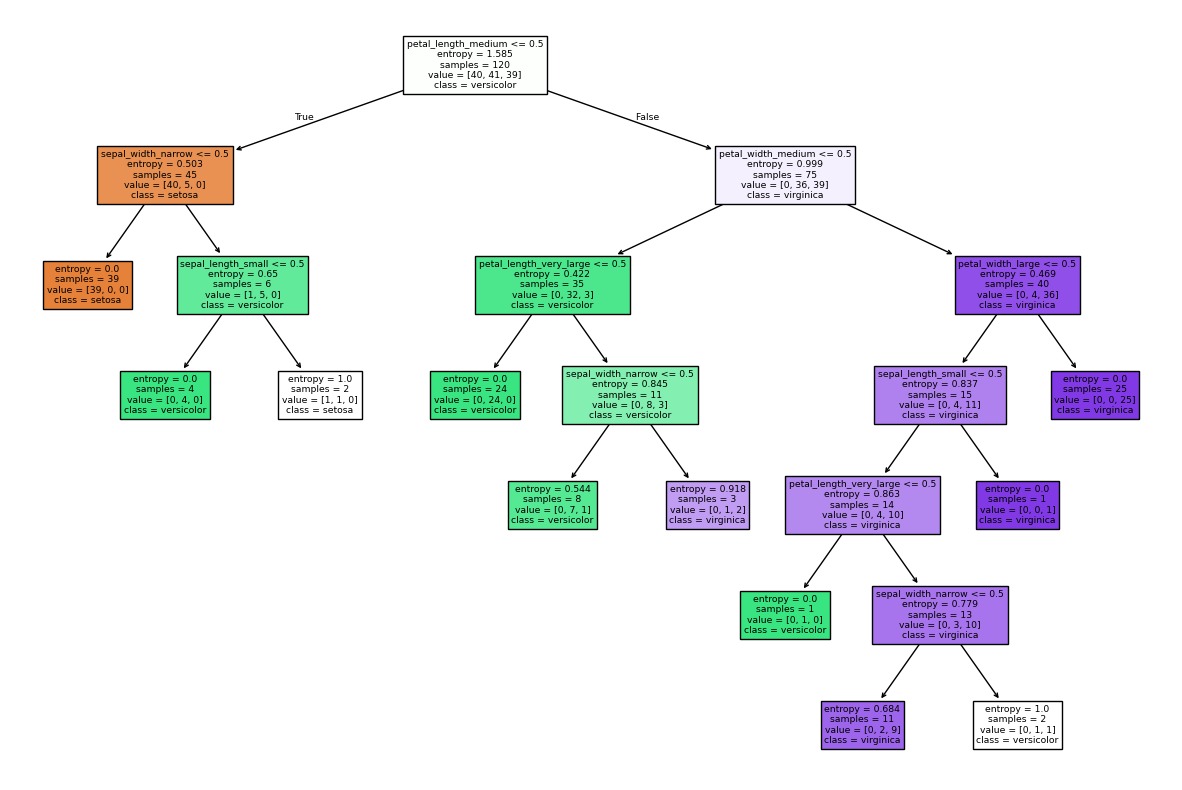

In [165]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=x.columns, class_names=model.classes_, filled=True)
plt.show()

In [166]:
tree = model.tree_
feature_names = x.columns

In [167]:
def ask_questions(node=0):
    
    if tree.feature[node] == -2:
        prediction = model.classes_[tree.value[node].argmax()]
        print("\n🎯 I guess:", prediction)
        return
    
    feature = feature_names[tree.feature[node]]
    
    answer = input(f"{feature}? (yes=1 / no=0): ")
    
    if int(answer) == 1:
        ask_questions(tree.children_right[node])
    else:
        ask_questions(tree.children_left[node])

In [168]:
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

In [169]:
def information_gain(df, feature, target="flower"):
    total_entropy = entropy(df[target])
    #split data
    df_yes = df[df[feature]==1]
    df_no = df[df[feature]==0]
    #weighted entropy
    w_yes = len(df_yes) / len(df)
    w_no = len(df_no) / len(df)
    
    cond_entropy = 0
    if len(df_yes) > 0:
        cond_entropy += w_yes * entropy(df_yes[target])
    if len(df_no) > 0:
        cond_entropy += w_no * entropy(df_no[target])
        
    return total_entropy - cond_entropy    

In [170]:
def best_feature(df, features):
    gains = {}
    
    for feature in features:
        gains[feature] = information_gain(df, feature)
    
    return max(gains, key=gains.get)

In [171]:
def dynamic_akinator(df):
    
    features = list(df.columns)
    features.remove("flower")
    
    while True:
        
        if len(df) == 1:
            print("\n🎯 I am sure:", df["flower"].values[0])
            return
        
        if len(df) == 0:
            print("❌ I don't know this flower.")
            return
        
        feature = best_feature(df, features)
        
        answer = input(f"{feature}? (yes=1 / no=0): ")
        
        df = df[df[feature] == int(answer)]
        
        features.remove(feature)
        
        if len(features) == 0:
            print("\n🤔 Possible answers:")
            print(df["flower"].values)
            return

In [175]:
dynamic_akinator(df_bin.copy())


🤔 Possible answers:
[np.str_('versicolor') np.str_('virginica') np.str_('virginica')]
